<div style="
border:3px solid #0f172a;
background-color:#f8fafc;
padding:18px;
font-size:17px;
font-family:'Trebuchet MS', sans-serif;
color:#0f172a;
border-radius:12px;
">

<span style="font-size:22px; font-weight:bold; color:#7c3aed;">
🔵 DBSCAN CLUSTERING – UNSUPERVISED LEANRING
</span>
<br><br>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r"C:\Users\shree\Downloads\DATA SCIENCE\UNSUPERVISED LEARNING.ipynb\Customer Data.csv")
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [2]:
df["MINIMUM_PAYMENTS"]=df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median())
df["CREDIT_LIMIT"]=df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())

In [6]:
df.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [4]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["CUST_ID"]=le.fit_transform(df["CUST_ID"])
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12
4,4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,312.343947,0.000000,6
8947,8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


<span style="color:GREEN; font-size:30px; font-weight:bold;">
📊 VISUALIZATION – UNSUPERVISED LEARNING
</span>

COUNT PLOT

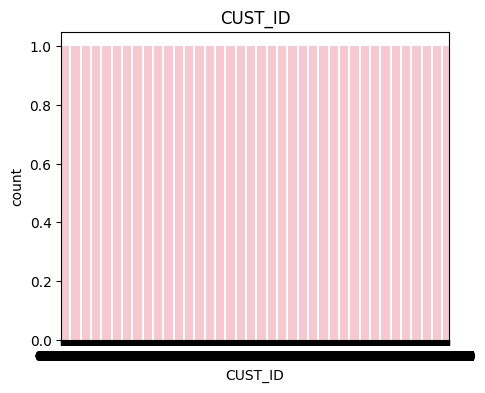

In [3]:
plt.figure(figsize=(5,4))
sns.countplot(x="CUST_ID",data=df,color="pink")
plt.title("CUST_ID")
plt.show()

BAR PLOT

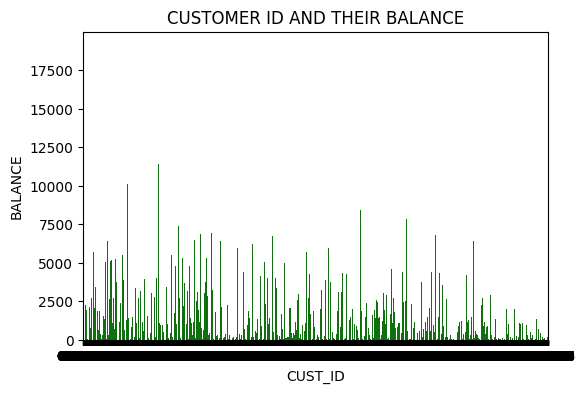

In [4]:
plt.figure(figsize=(6,4))
sns.barplot(x="CUST_ID",y="BALANCE",data=df,color="green")
plt.title("CUSTOMER ID AND THEIR BALANCE")
plt.show()

<span style="color:YELLOW; font-weight:bold; border:1px solid #1dd8c872; padding:5px;">
Most customers have low account balances, with only a few showing very high balances (tall spikes).
</span>

KDE PLOT

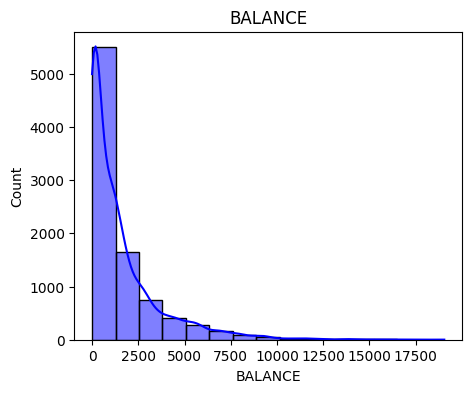

In [5]:
plt.figure(figsize=(5,4))
sns.histplot(x="BALANCE",bins=15,kde="True",data=df,color="blue")
plt.title("BALANCE")
plt.show()

<span style="color:VIOLET; font-weight:bold; padding:5px;">
The BALANCE distribution is highly right-skewed, with most customers holding low balances concentrated near zero.

A small number of customers maintain very high balances, creating a long right tail and visible outliers
</span>

BOX PLOT

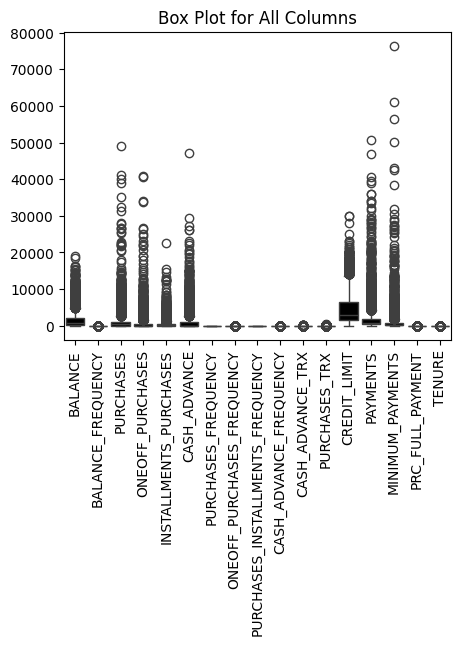

In [6]:
plt.figure(figsize=(5,4))
sns.boxplot(data=df, color="black")
plt.title("Box Plot for All Columns")
plt.xticks(rotation=90)
plt.show()

<span style="color:GREEN; font-weight:bold; padding:5px;">
Most monetary variables (BALANCE, PURCHASES, CASH_ADVANCE, CREDIT_LIMIT, PAYMENTS) are highly right-skewed with many extreme outliers, indicating large variation in customer spending behavior.

Frequency and tenure-related features are tightly clustered with fewer outliers, suggesting more stable and consistent usage patterns across customers.
</span>

SCATTER PLOT

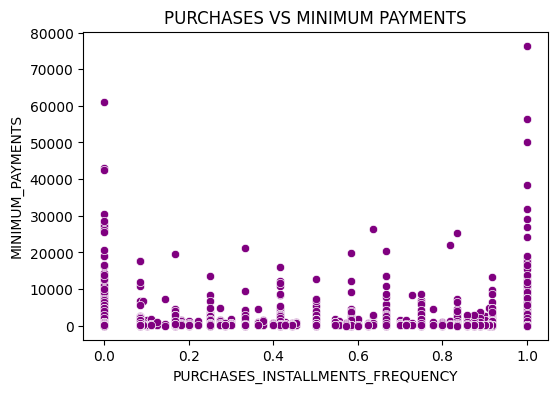

In [8]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="PURCHASES_INSTALLMENTS_FREQUENCY",y="MINIMUM_PAYMENTS",data=df,color="purple")
plt.title("PURCHASES VS MINIMUM PAYMENTS")
plt.show()

<span style="color:BLUE; font-weight:bold; padding:5px;">
There is no strong linear relationship between purchase installment frequency and minimum payments, as points are widely scattered.
</span>

HEAT MAP

In [9]:
numerical=df[["BALANCE","PURCHASES_FREQUENCY","PRC_FULL_PAYMENT","TENURE"]].corr()
numerical

,BALANCE,PURCHASES_FREQUENCY,PRC_FULL_PAYMENT,TENURE
BALANCE,1.000000,-0.077944,-0.318959,0.072692
PURCHASES_FREQUENCY,-0.077944,1.000000,0.305802,0.061506
PRC_FULL_PAYMENT,-0.318959,0.305802,1.000000,-0.016486
TENURE,0.072692,0.061506,-0.016486,1.000000


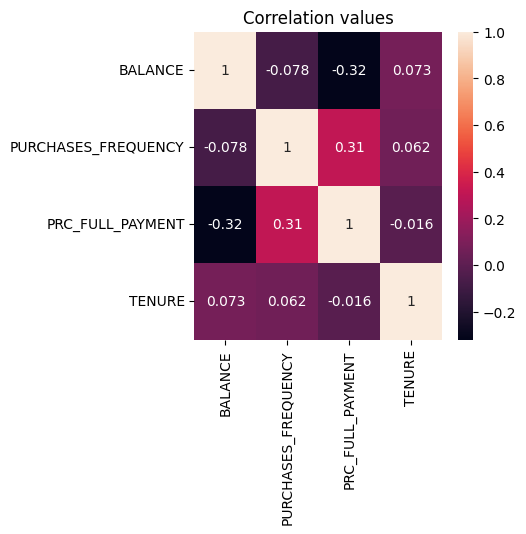

In [10]:
numerical
plt.figure(figsize=(4,4))
sns.heatmap(numerical,annot=True)
plt.title("Correlation values")
plt.show()

<span style="color:VIOLET; font-weight:bold; padding:5px;">
Balance shows a moderate negative correlation with full payment percentage, meaning higher balances tend to pay less in full.
</span>

<span style="color:RED; font-weight:bold; padding:10px;">
DEFINING INPUT AND OUTPUT COLUMN
</span>

In [34]:
x=df.drop(["PAYMENTS"],axis=1)
y=df["PAYMENTS"]
x

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,139.509787,0.000000,12,0
1,1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,1072.340217,0.222222,12,0
2,2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,627.284787,0.000000,12,0
3,3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,312.343947,0.000000,12,0
4,4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,244.791237,0.000000,12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,48.886365,0.500000,6,0
8946,8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,312.343947,0.000000,6,0
8947,8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,82.418369,0.250000,6,0
8948,8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,55.755628,0.250000,6,0


In [35]:
y

0        201.802084
1       4103.032597
2        622.066742
3          0.000000
4        678.334763
           ...     
8945     325.594462
8946     275.861322
8947      81.270775
8948      52.549959
8949      63.165404
Name: PAYMENTS, Length: 8950, dtype: float64

<span style="color:RED; font-weight:bold; padding:10px;">
SCALING AND CLUSTERING</span>

In [36]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x=sc.fit_transform(x)
x

array([[-1.73185729, -0.73198937, -0.24943448, ..., -0.52555097,
         0.36067954,  0.45965226],
       [-1.73147024,  0.78696085,  0.13432467, ...,  0.2342269 ,
         0.36067954,  0.45965226],
       [-1.73108319,  0.44713513,  0.51808382, ..., -0.52555097,
         0.36067954,  0.45965226],
       ...,
       [ 1.73108319, -0.7403981 , -0.18547673, ...,  0.32919999,
        -4.12276757,  0.45965226],
       [ 1.73147024, -0.74517423, -0.18547673, ...,  0.32919999,
        -4.12276757,  0.45965226],
       [ 1.73185729, -0.57257511, -0.88903307, ..., -0.52555097,
        -4.12276757, -2.15233995]], shape=(8950, 18))

In [37]:
from sklearn.cluster import DBSCAN
model=DBSCAN(eps=1.5,min_samples=8)
model.fit(x)

,eps,1.5
,min_samples,8
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [38]:
model.labels_

array([ 0,  0,  0, ...,  0,  0, -1], shape=(8950,))

In [39]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
model = DBSCAN(eps=1.5, min_samples=8)
clusters = model.fit_predict(x_scaled)  
df['Cluster'] = clusters
print(df['Cluster'].value_counts())


Cluster
 0    7061
-1    1889
Name: count, dtype: int64


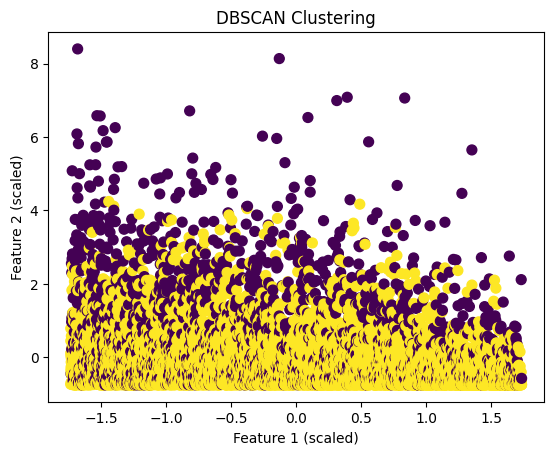

In [40]:
import matplotlib.pyplot as plt
plt.scatter(x_scaled[:,0], x_scaled[:,1], c=df['Cluster'], cmap='viridis', s=50)
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')
plt.title('DBSCAN Clustering')
plt.show()


<div style="
border:3px dashed #7c2d12;
background-color:#fff1f2;
padding:16px;
font-size:14px;
font-family:Georgia, serif;
color:#7c2d12;
border-radius:10px;
">

<strong style="font-size:19px; color:#9f1239;">Clusters:</strong><br>
There appear to be two main clusters. The <span style="color:#6d28d9; font-weight:bold;">purple points</span> represent the main dense cluster, while the <span style="color:#ca8a04; font-weight:bold;">yellow points</span> are more spread out and likely represent outliers or noise.
<br><br>

<strong style="font-size:19px; color:#9f1239;">Outliers:</strong><br>
Points higher along the y-axis (<em>Feature 2</em>) are scattered and sparse, indicating anomalous or less typical observations.
<br><br>

<strong style="font-size:19px; color:#9f1239;">Overall Insight:</strong><br>
The dataset contains one dense cluster at low Feature 2 values, a smaller sparse cluster, and a large number of outliers, showing how <span style="color:#be123c; font-weight:bold;">DBSCAN effectively separates dense regions from noise</span>.
</div>
